In [1]:
from google.colab import files
uploaded = files.upload()

import zipfile
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('.')

import os
if os.path.exists('casting_data/casting_data'):
    import shutil
    shutil.move('casting_data/casting_data/train', 'casting_data/train')
    shutil.move('casting_data/casting_data/test', 'casting_data/test')

Saving archive (3).zip to archive (3).zip


In [2]:
# !pip install tensorflow matplotlib scikit-learn seaborn

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [4]:
train_directory = "casting_data/train"
test_directory = "casting_data/test"

image_size = (224, 224)
batch_size = 32

class_names = ["ok_front", "def_front"]

In [5]:
def count_images(directory, class_names):
    counts = {}
    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)
        if os.path.isdir(class_dir):
            counts[class_name] = len([
                f for f in os.listdir(class_dir)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
            ])
        else:
            counts[class_name] = 0
    return counts

train_counts = count_images(train_directory, class_names)
test_counts = count_images(test_directory, class_names)

print("Training set image counts:", train_counts)
print("Test set image counts:", test_counts)

total_train = sum(train_counts.values())
if total_train > 0:
    balance_ratio = train_counts[class_names[0]] / total_train
    print(f"\nClass balance (train): {balance_ratio:.1%} non-defective / "
          f"{1 - balance_ratio:.1%} defective")

Training set image counts: {'ok_front': 2875, 'def_front': 3758}
Test set image counts: {'ok_front': 262, 'def_front': 453}

Class balance (train): 43.3% non-defective / 56.7% defective


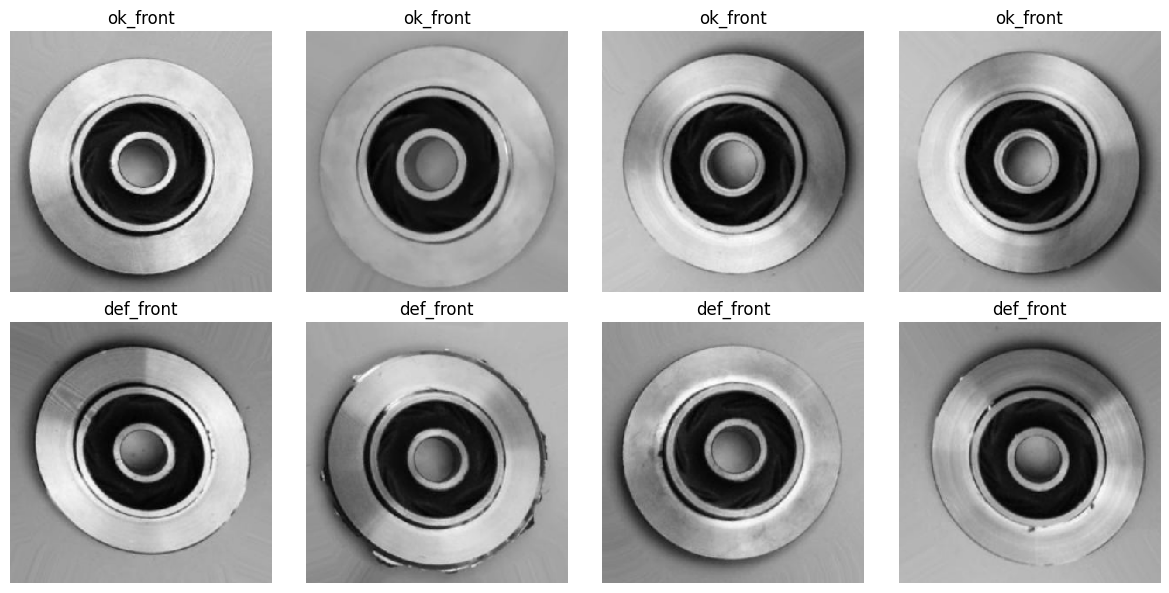

In [6]:
def show_sample_images(directory, class_names, n_per_class=4):
    fig, axes = plt.subplots(len(class_names), n_per_class, figsize=(3 * n_per_class, 3 * len(class_names)))
    for row, class_name in enumerate(class_names):
        class_dir = os.path.join(directory, class_name)
        if not os.path.isdir(class_dir):
            continue
        files = [f for f in os.listdir(class_dir) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))][:n_per_class]
        for col, fname in enumerate(files):
            img = tf.keras.utils.load_img(os.path.join(class_dir, fname), target_size=image_size)
            ax = axes[row, col] if len(class_names) > 1 else axes[col]
            ax.imshow(img)
            ax.set_title(class_name)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_images(train_directory, class_names)

In [7]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="training",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="validation",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_directory,
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Found 715 files belonging to 2 classes.


In [8]:
for images, labels in train_dataset.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Unique labels in batch:", np.unique(labels.numpy()))

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32, 1)
Unique labels in batch: [0. 1.]


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10)
], name="data_augmentation")

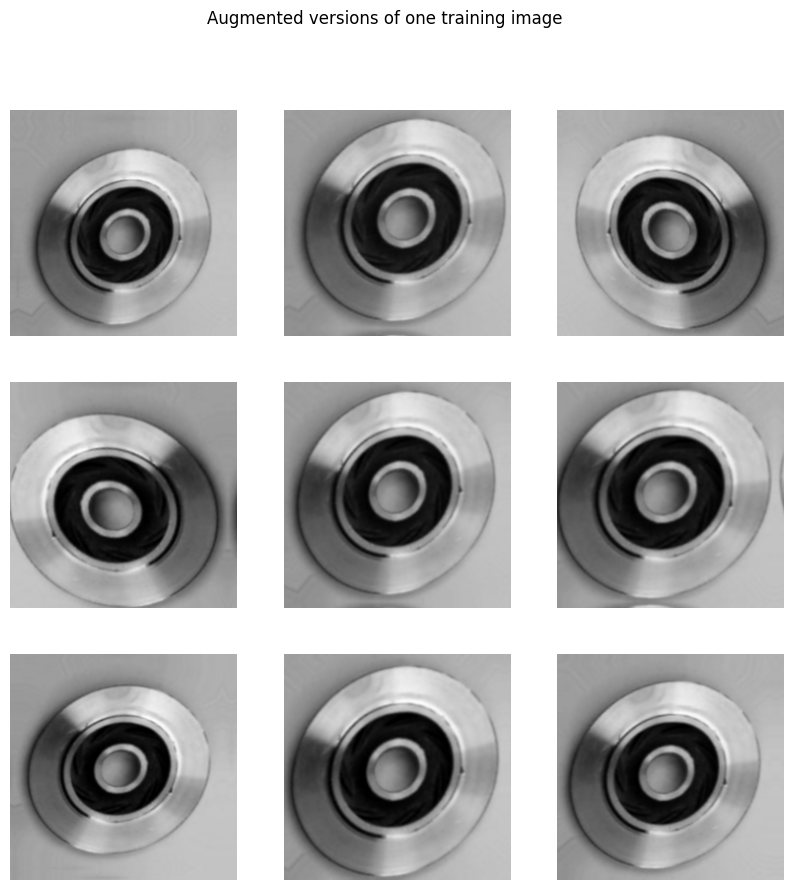

In [11]:
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(images[0], 0), training=True)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")
    plt.suptitle("Augmented versions of one training image")
    plt.show()

In [12]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.40),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [14]:
os.makedirs("models", exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.000001
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="models/best_casting_defect_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [15]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - accuracy: 0.5572 - loss: 0.6888 - precision: 0.5615 - recall: 0.9603 - val_accuracy: 0.5897 - val_loss: 0.6794 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.5596 - loss: 0.6863 - precision: 0.5610 - recall: 0.9876 - val_accuracy: 0.5897 - val_loss: 0.6800 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.5610 - loss: 0.6861 - precision: 0.5609 - recall: 1.0000 - val_accuracy: 0.5897 - val_loss: 0.6787 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.5685 - loss: 0.6809 - precision: 0.5682 - recall: 0.9600 - val_accuracy: 0.5897 - val_loss: 0.6623 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - 

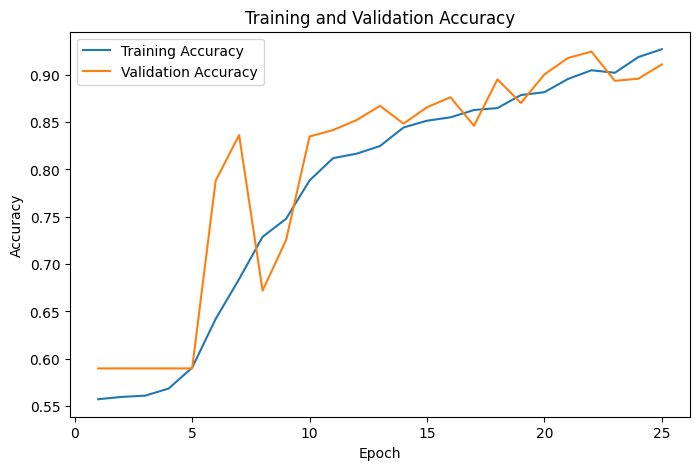

In [27]:
os.makedirs("reports", exist_ok=True)

training_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]
epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.savefig("reports/accuracy_graph.png", dpi=150, bbox_inches="tight")
plt.show()

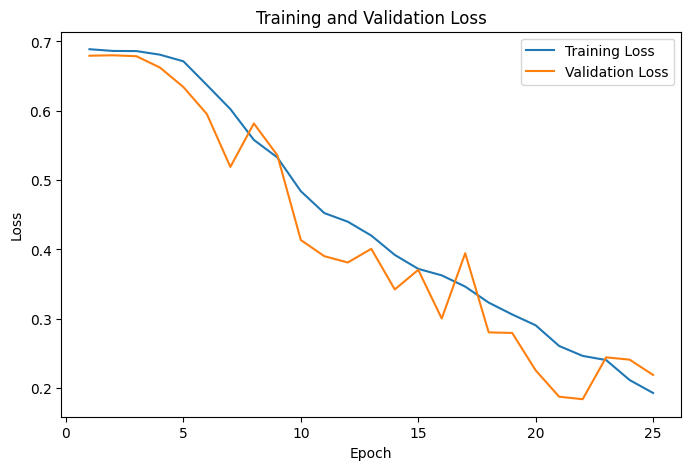

In [28]:
os.makedirs("reports", exist_ok=True)

training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]
epochs_range = range(1, len(training_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.savefig("reports/loss_graph.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
test_results = model.evaluate(test_dataset)
print("Test results (loss, accuracy, precision, recall):", test_results)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9091 - loss: 0.2090 - precision: 0.8911 - recall: 0.9757
Test results (loss, accuracy, precision, recall): [0.2090395987033844, 0.9090909361839294, 0.8911290168762207, 0.9757174253463745]


In [18]:
prediction_probabilities = model.predict(test_dataset)

predicted_labels = (prediction_probabilities.flatten() >= 0.5).astype(int)

actual_labels = np.concatenate([
    labels.numpy().flatten() for images, labels in test_dataset
]).astype(int)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [19]:
print(classification_report(
    actual_labels,
    predicted_labels,
    target_names=["Non-defective", "Defective"]
))

               precision    recall  f1-score   support

Non-defective       0.95      0.79      0.86       262
    Defective       0.89      0.98      0.93       453

     accuracy                           0.91       715
    macro avg       0.92      0.88      0.90       715
 weighted avg       0.91      0.91      0.91       715



[[208  54]
 [ 11 442]]

True Negatives:  208
False Positives: 54
False Negatives: 11
True Positives:  442


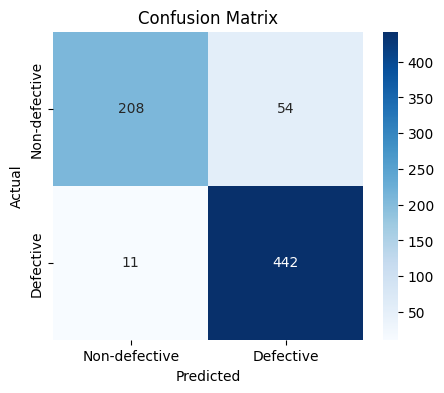

In [20]:
matrix = confusion_matrix(actual_labels, predicted_labels)
print(matrix)

tn, fp, fn, tp = matrix.ravel()
print(f"\nTrue Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-defective", "Defective"],
            yticklabels=["Non-defective", "Defective"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("reports/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
for threshold in [0.30, 0.40, 0.50, 0.60]:
    thresh_labels = (prediction_probabilities.flatten() >= threshold).astype(int)
    thresh_matrix = confusion_matrix(actual_labels, thresh_labels)
    tn, fp, fn, tp = thresh_matrix.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"Threshold {threshold:.2f} -> FP: {fp}, FN: {fn}, Precision: {precision:.2f}, Recall: {recall:.2f}")

Threshold 0.30 -> FP: 83, FN: 10, Precision: 0.84, Recall: 0.98
Threshold 0.40 -> FP: 63, FN: 11, Precision: 0.88, Recall: 0.98
Threshold 0.50 -> FP: 54, FN: 11, Precision: 0.89, Recall: 0.98
Threshold 0.60 -> FP: 47, FN: 23, Precision: 0.90, Recall: 0.95


In [22]:
def predict_product(image_path, model, threshold=0.50):
    image = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    image_array = tf.keras.utils.img_to_array(image)
    image_array = tf.expand_dims(image_array, axis=0)

    defect_probability = float(model.predict(image_array, verbose=0)[0][0])

    if defect_probability >= threshold:
        predicted_class = "Defective"
        recommended_action = "Send for manual inspection"
    else:
        predicted_class = "Non-defective"
        recommended_action = "Product may proceed"

    print(f"Prediction: {predicted_class}")
    print(f"Defect probability: {defect_probability:.2%}")
    print(f"Recommended action: {recommended_action}")
    return predicted_class, defect_probability

sample_image_paths = [
    "casting_data/test/ok_front/FILENAME1.jpeg",
    "casting_data/test/ok_front/FILENAME2.jpeg",
    "casting_data/test/def_front/FILENAME3.jpeg",
    "casting_data/test/def_front/FILENAME4.jpeg",
    "casting_data/test/def_front/FILENAME5.jpeg",
]

for path in sample_image_paths:
    if os.path.exists(path):
        print(f"--- {path} ---")
        predict_product(path, model, threshold=0.50)
        print()
    else:
        print(f"Skipping missing file: {path}")

Skipping missing file: casting_data/test/ok_front/FILENAME1.jpeg
Skipping missing file: casting_data/test/ok_front/FILENAME2.jpeg
Skipping missing file: casting_data/test/def_front/FILENAME3.jpeg
Skipping missing file: casting_data/test/def_front/FILENAME4.jpeg
Skipping missing file: casting_data/test/def_front/FILENAME5.jpeg


In [23]:
model.save("models/casting_defect_model_final.keras")
print("Model saved.")

Model saved.


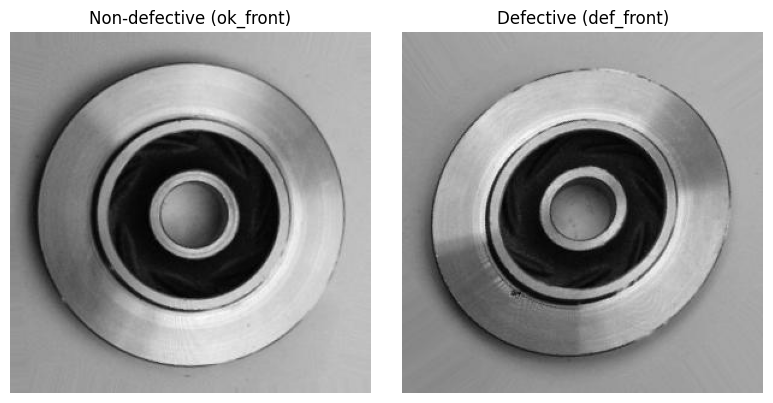

In [25]:
import shutil

ok_dir = "casting_data/test/ok_front"
def_dir = "casting_data/test/def_front"

ok_files = sorted(os.listdir(ok_dir))
def_files = sorted(os.listdir(def_dir))

shutil.copy(os.path.join(ok_dir, ok_files[0]), "reports/sample_ok_front.png")
shutil.copy(os.path.join(def_dir, def_files[0]), "reports/sample_def_front.png")

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
img_ok = tf.keras.utils.load_img("reports/sample_ok_front.png")
plt.imshow(img_ok)
plt.title("Non-defective (ok_front)")
plt.axis("off")

plt.subplot(1, 2, 2)
img_def = tf.keras.utils.load_img("reports/sample_def_front.png")
plt.imshow(img_def)
plt.title("Defective (def_front)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
files.download("reports/sample_ok_front.png")
files.download("reports/sample_def_front.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>